# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [3]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
missing_ratios = df.isnull().mean()
print("Tỷ lệ dữ liệu thiếu:\n", missing_ratios)
...

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
# điền danh sách cột cần bỏ (chỉ những cột có trong df)
leaky = ["class", "who","adult_male","deck","embark_town","alive","alone"]   

# df = df.drop(columns=...)
df = df.drop(columns=leaky)
print(df)

print("Các cột còn lại:", list(df.columns))
# print("Các cột còn lại:", list(df.columns))

Tỷ lệ dữ liệu thiếu:
 survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64
     survived  pclass     sex   age  sibsp  parch     fare embarked
0           0       3    male  22.0      1      0   7.2500        S
1           1       1  female  38.0      1      0  71.2833        C
2           1       3  female  26.0      0      0   7.9250        S
3           1       1  female  35.0      1      0  53.1000        S
4           0       3    male  35.0      0      0   8.0500        S
..        ...     ...     ...   ...    ...    ...      ...      ...
886         0       2    male  27.0      0      0  13.0000        S
887         1       1  female  19.0      0      0  30.0000 

**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

*(viết tại đây...)*

Vì alive là cột thừa mang thông tin tương đương với survived nên nó sẽ leak data và khiến việc train model trở nên vô nghĩa khi nó đã được học vẹt đáp án từ trước.

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [4]:
# TODO 2: shape, info, describe
print("Kích thước:", df.shape)
print("Biến mục tiêu (target) trong tập Titanic là cột survived, \nthể hiện việc hành khách có sống sót hay không")

df.info()
print("\n")

print("Mô tả biến số:")
display(df.describe())
...

print("Mô tả biến phân loại:")
display(df.describe(include="object"))

print("- Biến số: age, sibsp, parch, fare, pclass.")
print("- Biến phân loại: sex, embarked.")

Kích thước: (891, 8)
Biến mục tiêu (target) trong tập Titanic là cột survived, 
thể hiện việc hành khách có sống sót hay không
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


Mô tả biến số:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Mô tả biến phân loại:


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


- Biến số: age, sibsp, parch, fare, pclass.
- Biến phân loại: sex, embarked.


**Trả lời 2 (biến số vs biến phân loại):**

*(viết tại đây...)*

- Biến số: age, sibsp, parch, fare, pclass.
- Biến phân loại: sex, embarked.

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [5]:
# TODO 3: bảng missing (count + %)
...
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Số lượng (Count)': missing_count,
    'Phần trăm (%)': missing_percent
})
print("Bảng Missing Value:")
display(missing_df)

Bảng Missing Value:


,Số lượng (Count),Phần trăm (%)
survived,0,0.000000
pclass,0,0.000000
sex,0,0.000000
age,177,19.865320
sibsp,0,0.000000
parch,0,0.000000
fare,0,0.000000
embarked,2,0.224467


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| ... | ... | ... | ... |

- Cột age: 
    - Điền bằng trung vị (median).
    - Vì age là biến số và có thể chứa các giá trị ngoại lai (outliers), dùng median sẽ ổn định hơn so với mean.
- Cột embarked:
    - Điền bằng mode (giá trị xuất hiện nhiều nhất) hoặc xóa (drop)
    - Vì đây là biến phân loại dạng chuỗi (categorical) và tỷ lệ thiếu rất nhỏ (chỉ khoảng 0.2%), việc điền mode hoặc xóa hẳn 2 dòng này đều không ảnh hưởng nhiểu đến mô hình.

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [6]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
import numpy as np
from scipy import stats

def dem_outlier_iqr(s):
    ...    # trả về số lượng outlier theo IQR
    s_clean = s.dropna()
    
    Q1 = s_clean.quantile(0.25)
    Q3 = s_clean.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = s_clean[(s_clean < lower_bound) | (s_clean > upper_bound)]
    return len(outliers)

def dem_outlier_zscore(s, nguong=3.0):
    ...    # trả về số lượng outlier theo Z-score
    s_clean = s.dropna()
    
    z_scores = np.abs(stats.zscore(s_clean))
    
    outliers = s_clean[z_scores > nguong]
    return len(outliers)

for col in ["age", "fare"]:
#     ...
    so_luong_iqr = dem_outlier_iqr(df[col])
    so_luong_zscore = dem_outlier_zscore(df[col])
    print(f"Cột '{col}':")
    print(f" - Theo IQR    : {so_luong_iqr} outlier")
    print(f" - Theo Z-score: {so_luong_zscore} outlier")

Cột 'age':
 - Theo IQR    : 11 outlier
 - Theo Z-score: 2 outlier
Cột 'fare':
 - Theo IQR    : 116 outlier
 - Theo Z-score: 20 outlier


**Trả lời 4 (quyết định với outlier của `fare`):**

*(viết tại đây...)*

- Đối với các outlier của cột 'fare', ta nên giữ lại vì:
    - Giá vé (fare) cao bất thường không phải là lỗi nhập liệu, mà nó phản ánh thực tế về các hạng vé siêu sang (First Class) trên tàu Titanic.
    - Những hành khách mua vé giá rất cao này thường có tỷ lệ sống sót rất khác biệt so với phần còn lại (được ưu tiên lên thuyền cứu sinh). Nếu loại bỏ những dữ liệu này, mô hình máy học sẽ mất đi một đặc trưng (feature) cực kỳ quan trọng để dự đoán việc hành khách có sống sót hay không.
- Đối với các outlier của cột 'age', ta cũng nên giữ lại vì các outlier rơi vào nhóm hành khách lớn tuổi (70-80 tuổi), và độ tuổi cũng phản ánh khá rõ khả năng sống sót 


---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

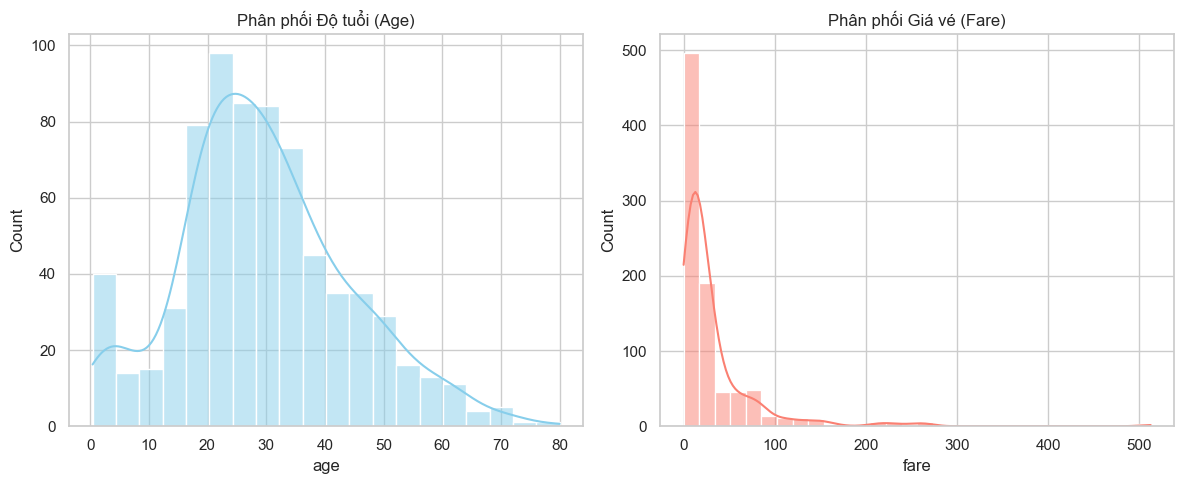

In [7]:
# TODO 5a: Histogram age & fare
...
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df, x='age', kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Phân phối Độ tuổi (Age)')

sns.histplot(data=df, x='fare', kde=True, ax=ax[1], color='salmon', bins=30)
ax[1].set_title('Phân phối Giá vé (Fare)')

plt.tight_layout()
plt.show()

- Cột 'age': Phân phối có dạng gần chuẩn nhưng hơi lệch phải, tập trung chủ yếu ở độ tuổi 20-30.
- Cột 'fare': Phân phối lệch phải rất mạnh. Đa số hành khách mua vé giá rẻ (dưới 50), chỉ có một số rất ít mua vé giá cực kỳ cao.

C:\Users\Admin\AppData\Local\Temp\ipykernel_15812\1945249914.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pclass', y='fare', palette='Set2')


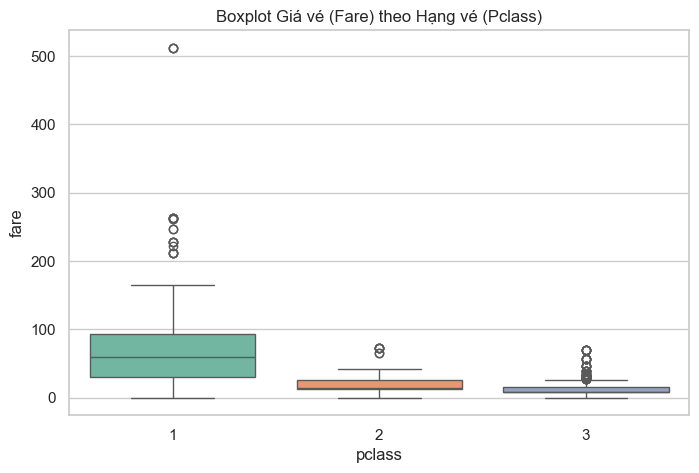

In [8]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
...
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='pclass', y='fare', palette='Set2')
plt.title('Boxplot Giá vé (Fare) theo Hạng vé (Pclass)')
plt.show()

- Trung vị (median): Giá vé trung vị giảm dần từ Hạng 1 xuống Hạng 3, điều này hoàn toàn hợp lý với thực tế.
- Outlier (ngoại lai): Hạng 1 (Pclass=1) có khoảng phân tán rộng nhất và xuất hiện các outlier có giá trị cực kỳ cao (trên 500). Hạng 2 và 3 có mức giá tập trung hẹp hơn nhưng vẫn xuất hiện nhiều điểm ngoại lai phía trên.

C:\Users\Admin\AppData\Local\Temp\ipykernel_15812\3890772434.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='sex', y='survived', ax=ax[0], palette='pastel')
C:\Users\Admin\AppData\Local\Temp\ipykernel_15812\3890772434.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='pclass', y='survived', ax=ax[1], palette='Set3')


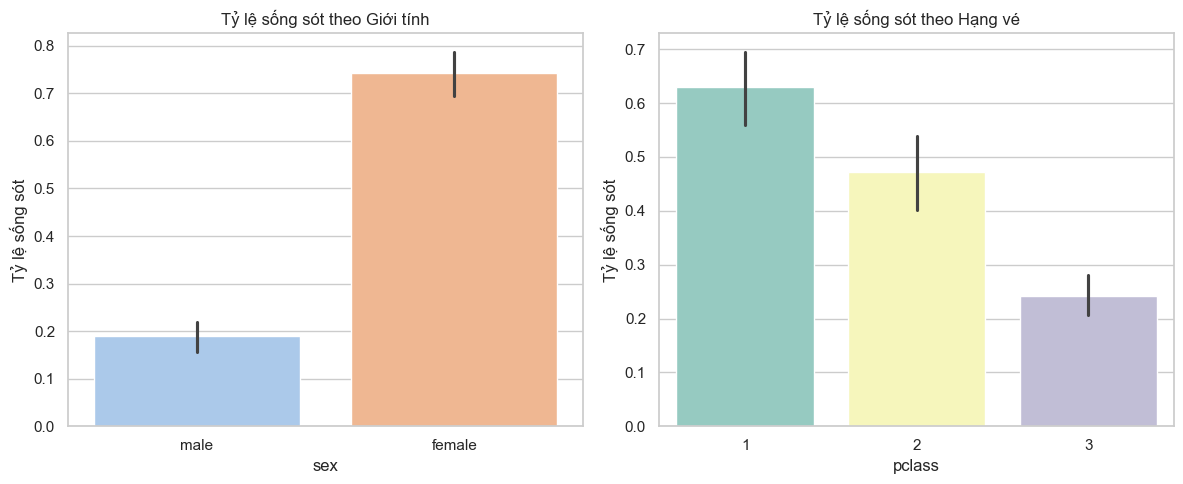

In [9]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
...
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, x='sex', y='survived', ax=ax[0], palette='pastel')
ax[0].set_title('Tỷ lệ sống sót theo Giới tính')
ax[0].set_ylabel('Tỷ lệ sống sót')

sns.barplot(data=df, x='pclass', y='survived', ax=ax[1], palette='Set3')
ax[1].set_title('Tỷ lệ sống sót theo Hạng vé')
ax[1].set_ylabel('Tỷ lệ sống sót')

plt.tight_layout()
plt.show()

- Theo giới tính: Phụ nữ (female) có tỷ lệ sống sót áp đảo (hơn 70%), trong khi nam giới (male) có tỷ lệ sống sót rất thấp (dưới 20%). Chênh lệch lên tới hơn 50%.
- Theo hạng vé: Khách Hạng 1 (Pclass=1) được ưu tiên cứu nạn cao nhất (tỷ lệ sống sót khoảng 60%), và giảm dần tới Hạng 3 (chỉ còn khoảng 24%).

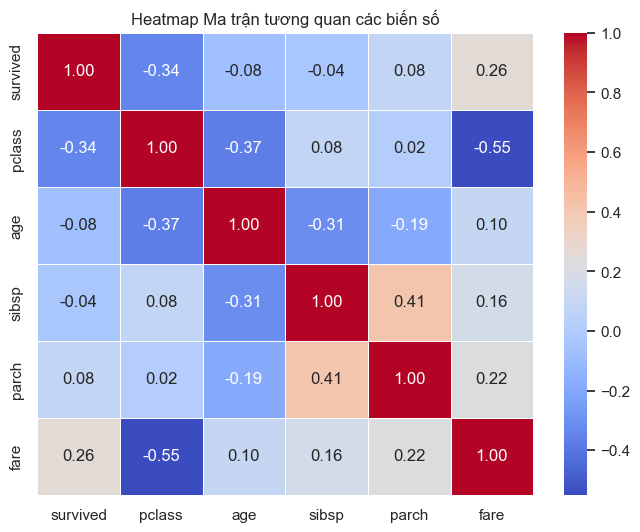

In [10]:
# TODO 5d: Heatmap correlation
...
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Ma trận tương quan các biến số')
plt.show()

- Tương quan mạnh nhất: Cặp 'pclass' và 'fare' có tương quan âm khá mạnh (-0.55), nghĩa là hạng vé số càng nhỏ (Hạng 1) thì giá vé càng cao.
- Tương quan với biến mục tiêu (survived): Cột 'survived' có tương quan dương với 'fare' (0.26) và tương quan âm với 'pclass' (-0.34). Điều này củng cố nhận định khách ở hạng cao, mua vé đắt có cơ hội sống sót cao hơn.

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram: ...
    - Cột 'age': Phân phối có dạng gần chuẩn nhưng hơi lệch phải, tập trung chủ yếu ở độ tuổi 20-30.
    - Cột 'fare': Phân phối lệch phải rất mạnh. Đa số hành khách mua vé giá rẻ (dưới 50), chỉ có một số rất ít mua vé giá cực kỳ cao.
- Boxplot: ...
    - Trung vị (median): Giá vé trung vị giảm dần từ Hạng 1 xuống Hạng 3, điều này hoàn toàn hợp lý với thực tế.
    - Outlier (ngoại lai): Hạng 1 (Pclass=1) có khoảng phân tán rộng nhất và xuất hiện các outlier có giá trị cực kỳ cao (trên 500). Hạng 2 và 3 có mức giá tập trung hẹp hơn nhưng vẫn xuất hiện nhiều điểm ngoại lai phía trên.
- Bar survival: ...
    - Theo giới tính: Phụ nữ (female) có tỷ lệ sống sót áp đảo (hơn 70%), trong khi nam giới (male) có tỷ lệ sống sót rất thấp (dưới 20%). Chênh lệch lên tới hơn 50%.
    - Theo hạng vé: Khách Hạng 1 (Pclass=1) được ưu tiên cứu nạn cao nhất (tỷ lệ sống sót khoảng 60%), và giảm dần tới Hạng 3 (chỉ còn khoảng 24%).
- Heatmap: ...
    - Tương quan mạnh nhất: Cặp 'pclass' và 'fare' có tương quan âm khá mạnh (-0.55), nghĩa là hạng vé số càng nhỏ (Hạng 1) thì giá vé càng cao.
    - Tương quan với biến mục tiêu (survived): Cột 'survived' có tương quan dương với 'fare' (0.26) và tương quan âm với 'pclass' (-0.34). Điều này củng cố nhận định khách ở hạng cao, mua vé đắt có cơ hội sống sót cao hơn.


---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [11]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns=['survived'])
y = df['survived']

# X_tmp, X_test, y_tmp, y_test = train_test_split(...)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

# X_train, X_val, y_train, y_val = train_test_split(...)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=15/85, stratify=y_temp, random_state=42)

# print("Train/Val/Test:", ...)
print("Kích thước các tập:")
print(f"- Tập Train: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"- Tập Val  : X_val   {X_val.shape}, y_val   {y_val.shape}")
print(f"- Tập Test : X_test  {X_test.shape}, y_test  {y_test.shape}")

# y.mean() chính là tỷ lệ số người sống (giá trị 1) trên tổng số
# in tỷ lệ survived từng tập
print("\nTỷ lệ survived:")
print(f"- Tỷ lệ gốc  : {y.mean():.4f}")
print(f"- Tập Train  : {y_train.mean():.4f}")
print(f"- Tập Val    : {y_val.mean():.4f}")
print(f"- Tập Test   : {y_test.mean():.4f}")

Kích thước các tập:
- Tập Train: X_train (623, 7), y_train (623,)
- Tập Val  : X_val   (134, 7), y_val   (134,)
- Tập Test : X_test  (134, 7), y_test  (134,)

Tỷ lệ survived:
- Tỷ lệ gốc  : 0.3838
- Tập Train  : 0.3836
- Tập Val    : 0.3881
- Tập Test   : 0.3806


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    # ("imputer", ...),
    # ("scaler",  ...),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

pipe_cat = Pipeline([
    # ("imputer", ...),
    # ("onehot",  ...),
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    # ("num", pipe_so,  num_cols),
    # ("cat", pipe_cat, cat_cols),
    # ("ord", "passthrough", ord_cols),
    ("num", pipe_so, num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols)
])

# preprocess.fit(X_train)               # fit CHỈ trên train
# X_train_t = preprocess.transform(X_train)
X_train_t = preprocess.fit_transform(X_train)

# ... transform cho val, test
X_val_preprocessed = preprocess.transform(X_val)
X_test_preprocessed = preprocess.transform(X_test)

# print(X_train_t.shape, list(preprocess.get_feature_names_out()))
print(X_train_t.shape, list(preprocess.get_feature_names_out()))

print("\nTên cột sau biến đổi:")
print(preprocess.get_feature_names_out())

(623, 10) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']

Tên cột sau biến đổi:
['num__age' 'num__sibsp' 'num__parch' 'num__fare' 'cat__sex_female'
 'cat__sex_male' 'cat__embarked_C' 'cat__embarked_Q' 'cat__embarked_S'
 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

*(viết tại đây...)*

- Ta chỉ gọi hàm fit trên tập X_train mà không fit trên toàn bộ dữ liệu là để ngăn chặn Data Leakage (Rò rỉ dữ liệu).
- Hàm fit đóng vai trò "học" các tham số thống kê từ dữ liệu (ví dụ: tính ra con số median của tuổi là bao nhiêu, tìm ra giá trị xuất hiện nhiều nhất của điểm đón khách, tính toán các mốc IQR để scale...).
- Nếu chúng ta fit trên toàn bộ dữ liệu, mô hình sẽ vô tình nhìn trộm được các đặc tính phân phối thống kê của cả tập Validation và Test.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [13]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
...
ty_le = df['survived'].value_counts(normalize=True) * 100
print("Tỷ lệ các lớp trong biến mục tiêu 'survived':")
print(ty_le)

Tỷ lệ các lớp trong biến mục tiêu 'survived':
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


**Trả lời 8:**

1. Có, dữ liệu có sự mất cân bằng nhưng ở mức độ nhẹ. Dựa vào kết quả tính toán, tỷ lệ người không sống sót (lớp 0) chiếm đa số với hơn 61%, trong khi người sống sót (lớp 1) chỉ chiếm khoảng 38%, thể hiện sự chênh lệch nhẹ, chưa đến mức quá nghiêm trọng (như 90% - 10%).
2. 
- Accuracy (Độ chính xác tổng thể) sẽ rất lừa dối khi tập dữ liệu bị mất cân bằng nghiêm trọng.
- Ví dụ: Giả sử ta có dữ liệu gồm 99% người chết và 1% người sống. Một mô hình "tệ" không học gì cả, chỉ cần nhắm mắt dự đoán "Chết" cho tất cả mọi người thì vẫn đạt Accuracy lên tới 99%. Nhìn vào 99% thì tưởng mô hình tốt, nhưng thực tế nó hoàn toàn vô dụng vì không tìm ra được bất kỳ ai sống sót.
3. ...
- Đề xuất ưu tiên: F1-Score (đặc biệt là F1-Score hướng tới lớp 1 - nhóm sống sót).
- Vì dữ liệu có sự mất cân bằng nhẹ, nếu dùng Accuracy thì kết quả có thể bị kéo lệch bởi nhóm đa số (nhóm Không sống sót). F1-Score là thước đo cân bằng hài hòa giữa Precision (Đoán ai sống thì chuẩn người đó) và Recall (Không bỏ sót những người còn sống), giúp ta đánh giá năng lực thực sự của mô hình trong việc nhận diện thiểu số một cách khách quan nhất.

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Đặc trưng tương quan mạnh nhất: Dựa vào biểu đồ Barplot và Heatmap, sex (giới tính) và pclass (hạng vé) là hai đặc trưng có sức mạnh dự đoán cao nhất. Dữ liệu chứng minh tỷ lệ sống sót của phụ nữ áp đảo (>70%) so với nam giới (<20%). Đồng thời, hệ số tương quan âm (-0.34) của pclass cho thấy khách Hạng 1 được ưu tiên cứu sống nhiều hơn hẳn khách Hạng 3.
2. Dữ liệu thiếu (Missing values): Cột deck bị thiếu trầm trọng nhất (>70%) nên đã được loại bỏ để tránh làm nhiễu mô hình. Tiếp theo là cột age (thiếu khoảng 20%), đã được xử lý bằng cách điền trung vị (median) thay vì trung bình (mean) nhằm hạn chế sự ảnh hưởng của các ngoại lai lớn tuổi.
3. Mất cân bằng lớp: Biến mục tiêu survived có sự mất cân bằng nhẹ (khoảng 62% Không sống sót : 38% Sống sót). Điều này có nghĩa là dùng Accuracy sẽ dễ bị ảo tưởng (mô hình chỉ cần đoán toàn bộ là chết cũng đạt accuracy cao). Do đó, F1-Score là metric được lựa chọn để đánh giá sự hài hòa giữa Precision và Recall cho nhóm thiểu số.
4. Scaling và Encoding: Các biến phân loại (sex, embarked) bắt buộc phải qua bước One-Hot Encoding vì thuật toán chỉ hiểu những con số, không hiểu chữ. Các biến số như age, fare, sibsp, parch cần được Scaling để đưa về cùng một thang đo, giúp các thuật toán không bị thiên vị bởi cột fare có giá trị quá lớn so với các cột còn lại.
5. Việc xuất hiện các điểm ngoại lai (outliers) ở cột fare thoạt nhìn giống như lỗi nhập liệu cần xóa bỏ. Nhưng khi phân tích kỹ, đây lại là giá vé Hạng nhất có thật. Việc giữ lại các outlier này lại cung cấp dữ liệu giá trị cho mô hình, vì những người mua vé hạng sang có tỷ lệ sống sót rất cao.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [14]:
# (tùy chọn) code cho phần Bonus
...

Ellipsis

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
